<a href="https://colab.research.google.com/github/mohammedibrahimshawon/Computer_Vision_assignmentS26/blob/main/exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Exercise Sheet 3: Image Center, Edges, Keypoints
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1.
2.
3.
4.
5.


In [1]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

Cloning into 'cs4250'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 94 (delta 41), reused 68 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.26 MiB | 27.41 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation

%matplotlib inline

## Exercise 3.1
### Finding the Image Center
Camera calibration refers to the process of computing the intrinsic and extrinsic parameters of the camera. It is a necessary step in many computer vision applications such as 3D scene reconstruction and recognition. One important intrinsic parameter is the image center. Print out the images `ueb311.jpg` and `ueb312.jpg` and estimate the image centers by using a ruler.

**Hint**: Make small printouts of the images to have enough space around them.

In [3]:
def load_image_gray(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image

In [4]:
def load_image_gray_normalized(image_path):
    return load_image_gray(image_path).astype('float32')/255.

In [5]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y


## Exercise 3.2.1
### Edge Detection
Open the image `ueb32.jpg` in Python and show the image gradients $d_x$ and $d_y$. Compute the magnitude of gradients image and apply a threshold to retain only the edges of the object. For those edges, compute and show the gradient angle image (`np.arctan2`). How can you tell the angle of the gradient from looking only at the gradients?

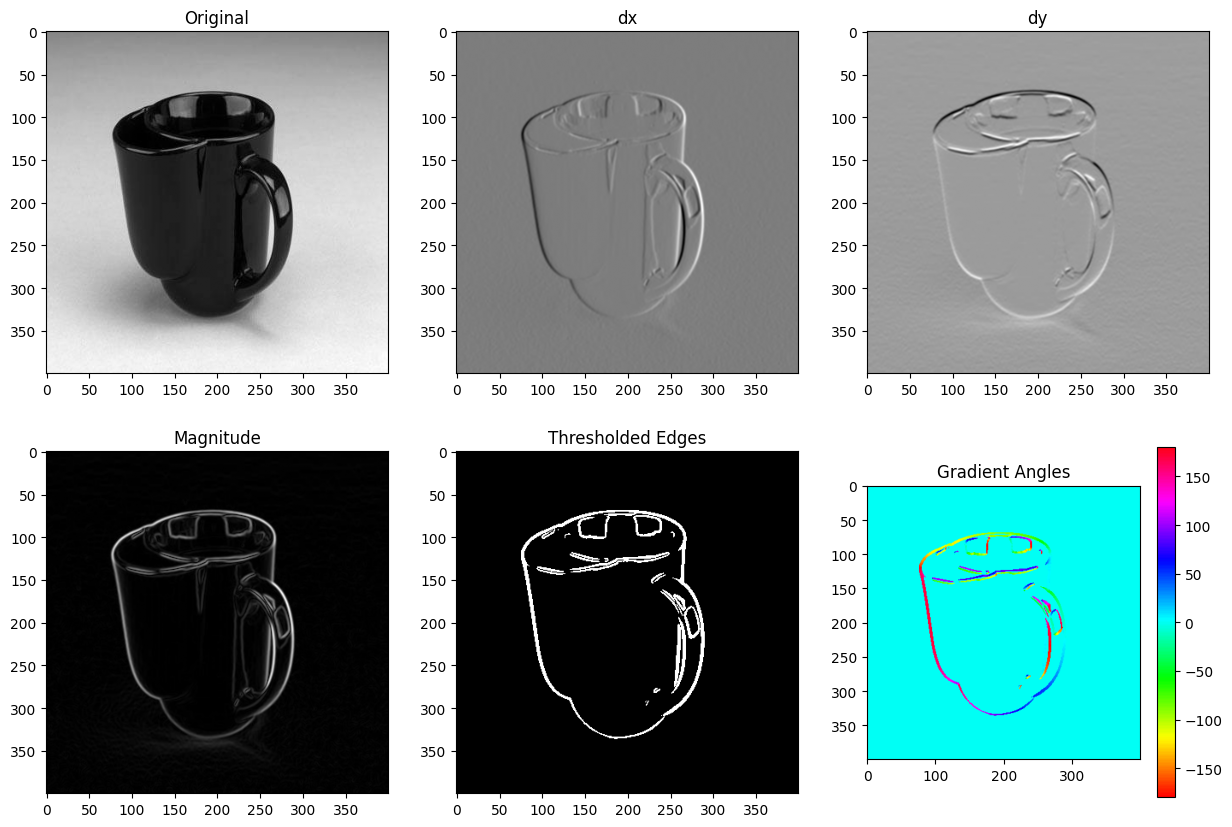

In [8]:
# load image
image = load_image_gray_normalized("data/exercise_3/ueb32.jpg")

# smooth image
image_blur = cv2.GaussianBlur(image, (5,5), 1)

# compute gradients
dx, dy = gradient(image_blur)

# compute gradient magnitude
magnitude = np.sqrt(dx**2 + dy**2)

# threshold for real edges
threshold = 0.2 * magnitude.max()
edges = magnitude > threshold

# angle image [-180,+180]
angles = np.degrees(np.arctan2(dy, dx))

# show angles only at edges
angle_edges = np.zeros_like(angles)
angle_edges[edges] = angles[edges]

# display
fig, ax = plt.subplots(2,3, figsize=(15,10))

ax[0,0].imshow(image, cmap='gray')
ax[0,0].set_title("Original")

ax[0,1].imshow(dx, cmap='gray')
ax[0,1].set_title("dx")

ax[0,2].imshow(dy, cmap='gray')
ax[0,2].set_title("dy")

ax[1,0].imshow(magnitude, cmap='gray')
ax[1,0].set_title("Magnitude")

ax[1,1].imshow(edges, cmap='gray')
ax[1,1].set_title("Thresholded Edges")

im = ax[1,2].imshow(angle_edges, cmap='hsv', vmin=-180, vmax=180)
ax[1,2].set_title("Gradient Angles")

plt.colorbar(im, ax=ax[1,2])
plt.show()

## Exercise 3.2.2
### Canny Edge Detector
Open the image `ueb32.jpg` in Python and use the OpenCV Canny algorithm to find the edges in the image.
Compare the result with the magnitude of gradient image. Display both results side by side using `plt.subplots`.
Comment on how the two results differ and why.**Furthermore, comment how the angle image and the magnitude image are used in the Canny algorithm.**

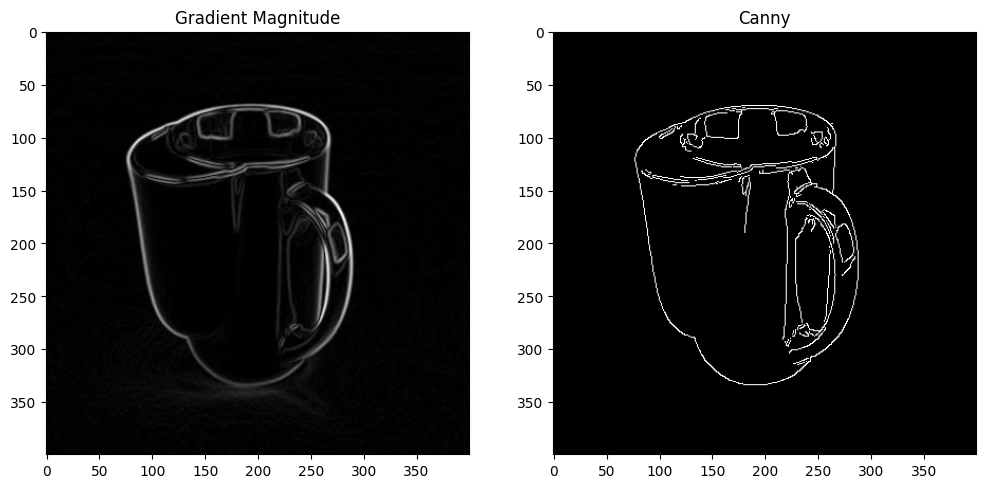

In [10]:
# load image
image = load_image_gray_normalized("data/exercise_3/ueb32.jpg")

# smooth image
blur = cv2.GaussianBlur(image, (5,5), 1)

# gradient magnitude
dx, dy = gradient(blur)
magnitude = np.sqrt(dx**2 + dy**2)

# canny expects uint8 image
image_uint8 = (image * 255).astype(np.uint8)

# apply canny
canny = cv2.Canny(image_uint8, 50, 150)

# compare
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(magnitude, cmap='gray')
ax[0].set_title("Gradient Magnitude")

ax[1].imshow(canny, cmap='gray')
ax[1].set_title("Canny")

plt.show()

## Exercise 3.3
### Key Point Detection
Implement the following key-point detectors:
* local maxima of $K$
* local maxima of $K$ − $\alpha$ $H^2$, with $\alpha$ as weighting parameter

The function is supposed to return images of the same size as the input, where the pixels contain $K$ or $K$ − $\alpha$ $H^2$.

$K$ and $H$ should be the invariants of the structure tensor $J$ (see script).
Evaluate the detectors above on two kinds of test images: (i) the synthetic image `ueb331.npy`, (ii) the
picture `ueb332.jpg`.

Comment your results with a focus on
1. the localization of the key points
2. the influence of the $H$ term as controlled via the parameter $\alpha$.

**Question**: Why do you filter the image with a Gaussian kernel a second time? It is **not** about noise removal!

**Hint**: Use the provided functions `find_local_max` and `plot_marks`.

In [11]:
def find_local_max(keypoints, thres=1e-6, k=3):
    kernel = np.ones((k, k))
    kernel[k//2, k//2] = 0
    local_max = keypoints > thres + dilation(keypoints, kernel)

    return local_max

In [12]:
def plot_marks(map, ax=None):
    if ax is None:
        _, ax = plt.subplots(1)
    col, row = np.nonzero(map)

    ax.plot(row, col, 'r.')

In [13]:
def key_points_structure(image, alpha, sigma=.1):

    # 0. Gaussian smoothing
    image = cv2.GaussianBlur(image, (0,0), sigma)

    # 1. derivatives
    Ix, Iy = gradient(image)

    # 2. product images
    Ix2 = Ix * Ix
    Iy2 = Iy * Iy
    Ixy = Ix * Iy

    # 3. second Gaussian smoothing
    J11 = cv2.GaussianBlur(Ix2, (0,0), 1)
    J22 = cv2.GaussianBlur(Iy2, (0,0), 1)
    J12 = cv2.GaussianBlur(Ixy, (0,0), 1)

    # 4. invariants
    H = J11 + J22

    K = J11 * J22 - J12**2

    K_minus_H = K - alpha * (H**2)

    return K, K_minus_H

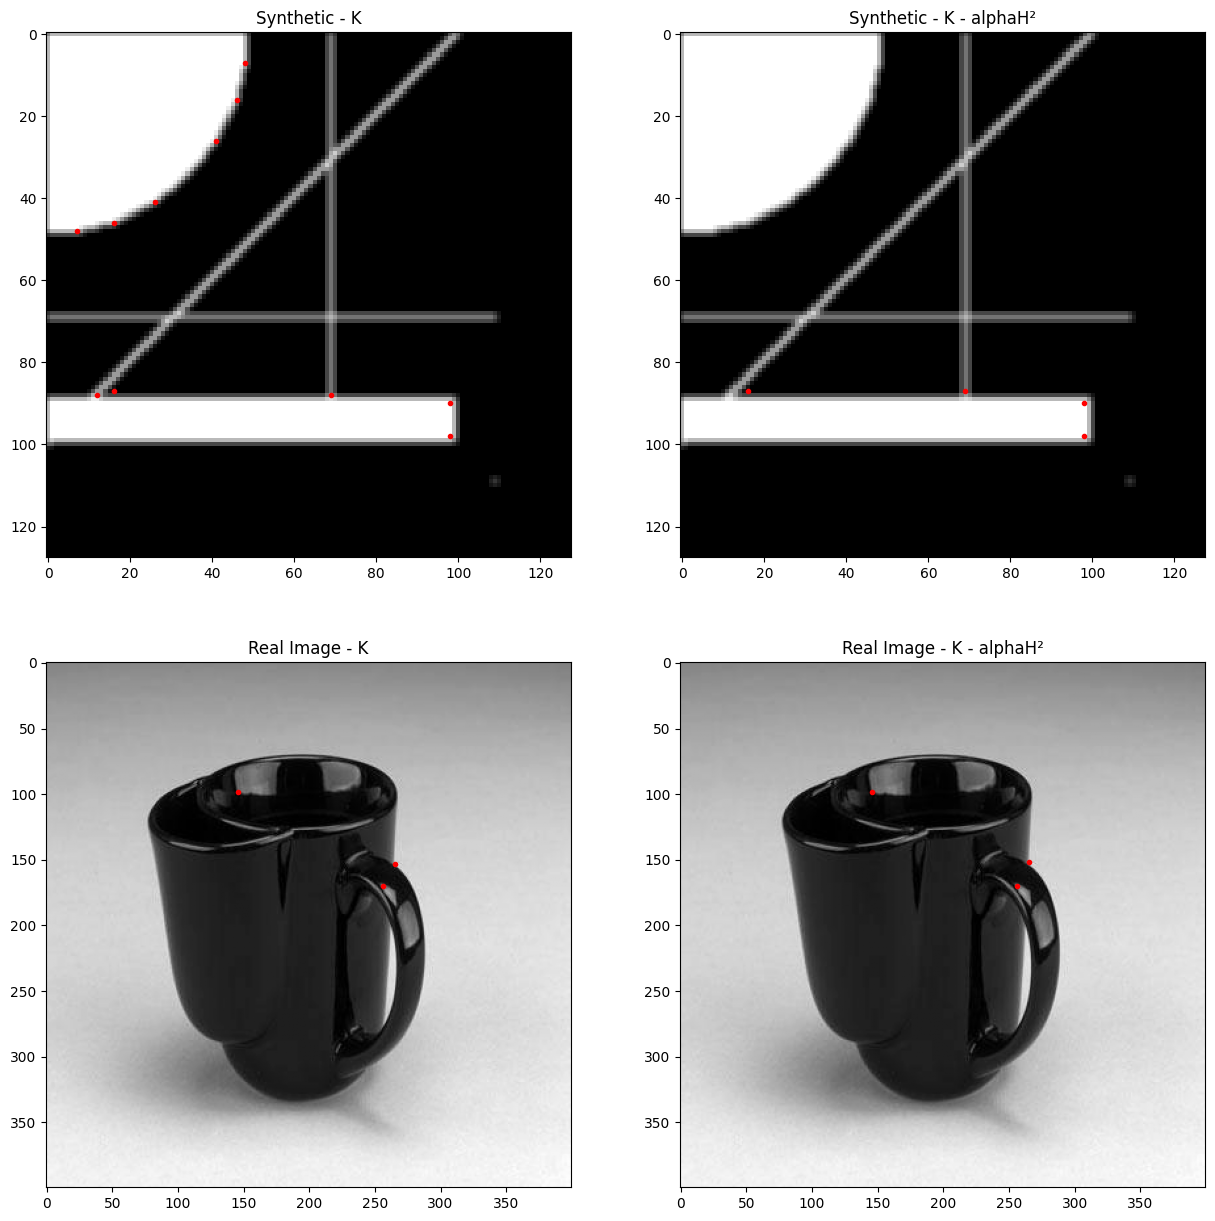

In [15]:
alpha = 0.04
sigma = 1.0
k = 5

# synthetic image
img1 = np.load("data/exercise_3/ueb331.npy")

# real image
img2 = load_image_gray_normalized("data/exercise_3/ueb332.jpg")

K1, KH1 = key_points_structure(img1, alpha, sigma)
K2, KH2 = key_points_structure(img2, alpha, sigma)

fig, ax = plt.subplots(2,2, figsize=(15,15))

# synthetic K
local_max = find_local_max(K1, k=k)
ax[0,0].imshow(img1, cmap='gray')
plot_marks(local_max, ax[0,0])
ax[0,0].set_title("Synthetic - K")

# synthetic K-alphaH²
local_max = find_local_max(KH1, k=k)
ax[0,1].imshow(img1, cmap='gray')
plot_marks(local_max, ax[0,1])
ax[0,1].set_title("Synthetic - K - alphaH²")

# real image K
local_max = find_local_max(K2, k=k)
ax[1,0].imshow(img2, cmap='gray')
plot_marks(local_max, ax[1,0])
ax[1,0].set_title("Real Image - K")

# real image K-alphaH²
local_max = find_local_max(KH2, k=k)
ax[1,1].imshow(img2, cmap='gray')
plot_marks(local_max, ax[1,1])
ax[1,1].set_title("Real Image - K - alphaH²")

plt.show()